# Pràctica III - ``PyTorch``

<a href="https://pytorch.org/"> ![PyTorch](https://pypi-camo.freetls.fastly.net/ed3839e1c11e779b508097969affa63d0968692b/68747470733a2f2f6769746875622e636f6d2f7079746f7263682f7079746f7263682f7261772f6d61696e2f646f63732f736f757263652f5f7374617469632f696d672f7079746f7263682d6c6f676f2d6461726b2e706e67) </a>


``PyTorch`` és una de les biblioteques més utilitzades actualment en l’àmbit de la intel·ligència artificial i l’aprenentatge automàtic. Desenvolupada inicialment per Facebook AI Research (FAIR), s’ha consolidat com una eina de referència per a investigadors i professionals gràcies a la seva flexibilitat, senzillesa d’ús i potència en el càlcul numèric.

Una de les grans fortaleses de ``PyTorch`` és el seu model de gràfic dinàmic (define-by-run). Això significa que la definició del flux de càlcul es construeix i s’executa de manera simultània, cosa que facilita el desenvolupament i la depuració de models complexos. Aquesta flexibilitat contrasta amb altres marcs que utilitzen gràfics estàtics, i ha fet que ``PyTorch`` sigui especialment popular en la recerca acadèmica.

En aquesta assignatura treballarem amb ``PyTorch`` per comprendre els fonaments de l’aprenentatge profund, implementar xarxes neuronals i experimentar amb diferents arquitectures.

### Conceptes claus

- **Tensor.** Estructura de dades multidimensional (com un array de NumPy) que pot viure a CPU o GPU i registrar les operacions que se li apliquen.
- **Autograd.** Mòdul de `PyTorch` que calcula automàticament derivades a partir del graf de computació.
- **Capa.** Conjunt de perceptrons (neurones artificials) organitzats en paral·lel. Cada perceptró calcula una combinació lineal de les entrades amb uns pesos i un biaix; la capa combina totes les sortides per generar la representació següent.
- **Funció d'activació.** Introdueix no-linealitat entre capes. Sense ella, una xarxa de qualsevol profunditat seria només una transformació lineal. Exemples habituals: ReLU, sigmoide i tanh.
- **Funció de pèrdua.** Mesura la diferència entre la sortida del model i la resposta desitjada; és la guia per saber si l'aprenentatge millora.
- **Optimitzador.** Algoritme (SGD, Adam…) que actualitza els paràmetres a partir dels gradients.
- **Learning rate (`lr`).** Mida del pas que fa l'optimitzador a cada actualització. Massa gran, l'entrenament divergeix; massa petit, és lentíssim.
- **Època i *batch*.** Una època és un recorregut complet pel conjunt d'entrenament. Aquest es pot processar d'un sol cop (*full-batch*) o en trossos (*mini-batches*); cada actualització de pesos és una *iteració*.


## Exemple guiat

Entrenar un model amb `PyTorch` requereix més codi que amb `scikit-learn` (hem d'escriure el bucle d'entrenament nosaltres mateixos), però a canvi tenim control total sobre l'arquitectura i el procés d'aprenentatge, i podem executar-ho en GPU. Comencem amb dades sintètiques.

In [1]:
import copy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

train: 201  test: 99


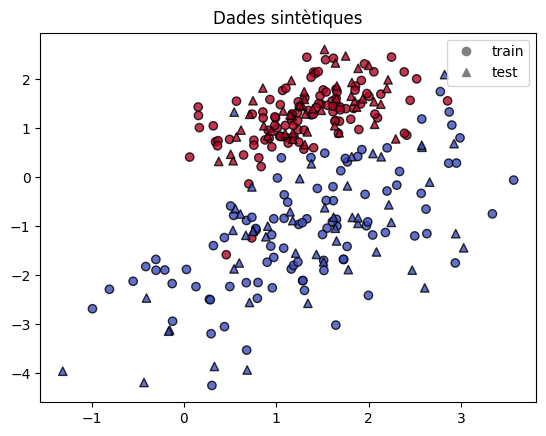

In [2]:
# Generació del conjunt de mostres
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_repeated=0,
                           n_classes=2, n_clusters_per_class=1, class_sep=1.25,
                           random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print(f"train: {len(X_train)}  test: {len(X_test)}")

# Visualització: el color indica la classe i la forma el conjunt
plt.figure(1)
for Xs, ys, marker in [(X_train, y_train, "o"), (X_test, y_test, "^")]:
    plt.scatter(Xs[:, 0], Xs[:, 1], c=ys, cmap="coolwarm", marker=marker, edgecolor="k", alpha=0.8)
    # plt.scatter(X_train[:, 0], X_train[:, 1], c=(y_train==0))  # Mostram el conjunt de mostres el color indica la classe
plt.legend(handles=[Line2D([], [], marker=m, color="gray", ls="", label=l)
                   for m, l in [("o", "train"), ("^", "test")]])
plt.title("Dades sintètiques")
plt.show()

### Definim el model

A `PyTorch`, un model és una classe que hereta de `nn.Module` i conté:

1. El **constructor** (`__init__`), on es defineixen les capes (`nn.Linear`, `nn.Conv2d`…).
2. El mètode **`forward`**, que especifica com passen les dades per les capes i les funcions d'activació.

Una capa lineal es defineix com:

```python
nn.Linear(in_features, out_features)
```

- `in_features`: nombre de valors que rep cada neurona (dimensió de l'entrada).
- `out_features`: nombre de neurones de la capa (dimensió de la sortida).

La regla bàsica és que `out_features` d'una capa ha de coincidir amb `in_features` de la següent. Els pesos i el biaix s'inicialitzen aleatòriament (per això convé fixar la llavor).

El model següent té **una sola capa lineal**. Amb una sigmoide a la sortida és equivalent a una **regressió logística** (el perceptró clàssic de Rosenblatt usa una funció esglaó en lloc de la sigmoide). Observau que el `forward` retorna *logits* (valors sense acotar) i **no** aplica la sigmoide: la funció de pèrdua que usarem ja la incorpora.

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 1)

    def forward(self, x):
        x = self.fc1(x)

        return x

### Entrenament

Entrenar una xarxa implica quatre ingredients: una **funció de pèrdua**, un **optimitzador**, un **bucle d'entrenament** i una **avaluació** correcta.

### 1. Funció de pèrdua

La **funció de pèrdua** mesura la diferència entre les prediccions del model i les etiquetes reals. Tot seguit teniu un conjunt de funcions de pèrdua per a classificació.

| Funció | Què ha de retornar el model | Etiquetes | Quan usar-la |
|---|---|---|---|
| `nn.BCEWithLogitsLoss` | 1 *logit* per mostra (sense sigmoide) | 0/1 en `float`, forma `(N, 1)` | Classificació binària |
| `nn.BCELoss` | 1 probabilitat (amb sigmoide) | 0/1 en `float`, forma `(N, 1)` | Binària; numèricament menys estable |
| `nn.CrossEntropyLoss` | *C* logits per mostra (sense softmax) | Índex de classe en `long`, forma `(N,)` | Multiclasse (o binària amb *C* = 2) |




**Error freqüent:** aplicar `sigmoid`/`softmax` a la sortida del model **i** usar `BCEWithLogitsLoss`/`CrossEntropyLoss`. Aquestes pèrdues ja l'apliquen internament; fer-ho dues vegades degrada l'aprenentatge sense donar cap error.

### 2. Optimitzador

Un optimitzador actualitza els paràmetres del model utilitzant els gradients calculats durant el backpropagation.

Exemple amb descens estocàstic de gradient (SGD):

```python
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
```

**Adam**:
```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
```

---

### 3. Bucle d’entrenament

Aquest és el nucli del procés d’entrenament. Per a cada època (un recorregut complet pel conjunt de dades), es repeteixen sempre els mateixos passos, **en aquest ordre**:

1. `optimizer.zero_grad()`: reiniciam els gradients (`PyTorch` els *acumula* per defecte; si s'oblida, l'entrenament és incorrecte).
2. `outputs = model(inputs)`: *forward pass*.
3. `loss = criterion(outputs, targets)`: càlcul de la pèrdua.
4. `loss.backward()`: *backward pass* (càlcul dels gradients).
5. `optimizer.step()`: actualització dels paràmetres.

```python
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(inputs), targets)
    loss.backward()
    optimizer.step()
```

Quan el conjunt és gran no es processa sencer a cada iteració, sinó en *mini-batches* amb `DataLoader`:

```python
from torch.utils.data import TensorDataset, DataLoader

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
for epoch in range(num_epochs):
    model.train()
    for xb, yb in loader:              # una iteració per mini-batch
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
```

#### 4. Avaluació

- `model.train()` / `model.eval()` canvien el comportament de capes com *dropout* o *batch normalization*. Cal posar el model en `eval()` per avaluar i tornar a `train()` per entrenar.
- `torch.no_grad()` desactiva el càlcul de gradients: estalvia memòria i temps quan només volem prediccions.

```python
model.eval()
with torch.no_grad():
    predictions = model(X_val)
```

Per triar el millor model o els hiperparàmetres s'usa el conjunt de **validació**. El conjunt de **test** només es consulta una vegada, al final. Si s'usa el test per prendre decisions, ja no és una estimació honesta del rendiment.

#### 5. Dispositiu (opcional)

Per entrenar en GPU, es mouen model i dades al mateix dispositiu:

```python
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device); X = X.to(device)
```

En aquesta pràctica treballam amb dades petites, de manera que la CPU és suficient.

---

## Resum

| Pas                | Propòsit                                           |
|--------------------|---------------------------------------------------|
| Funció de pèrdua   | Mesurar l’error de predicció                      |
| Optimitzador       | Actualitzar els pesos utilitzant els gradients   |
| Forward Pass       | Predir les sortides                               |
| Pèrdua + Backward  | Calcular els gradients                             |
| Pas de l’optimitzador | Ajustar els pesos                               |
| Zero Grad          | Evitar l’acumulació de gradients                  |
| Avaluació          | Provar el rendiment sense calcular gradients      |



In [4]:
torch.manual_seed(42)

In [5]:
LR = 1e-3
EPOCHS = 1000

criterion = nn.BCEWithLogitsLoss()

In [6]:
best_acc = 0
best_weights = None

losses = []
accuracies = []
accuracies_val = []

net = MLP()
optimizer = torch.optim.Adam(net.parameters(), lr=LR)

for epoch in range(EPOCHS):
    net.train()
    output = net(torch.Tensor(X_train))
    loss = criterion(output, torch.Tensor(y_train).reshape(-1, 1))

    losses.append(loss.detach().numpy())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    net.eval()
    output_val = net(torch.Tensor(X_test))

    acc = accuracy_score(y_train, (output.detach() > 0).int())
    acc_val = accuracy_score(y_test, (output_val.detach() > 0).int())

    if acc_val > best_acc:
        best_acc = acc_val
        best_weights = copy.deepcopy(net.state_dict())

    accuracies.append(acc)
    accuracies_val.append(acc_val)

net.load_state_dict(best_weights);

**Visualitzam els resultats**

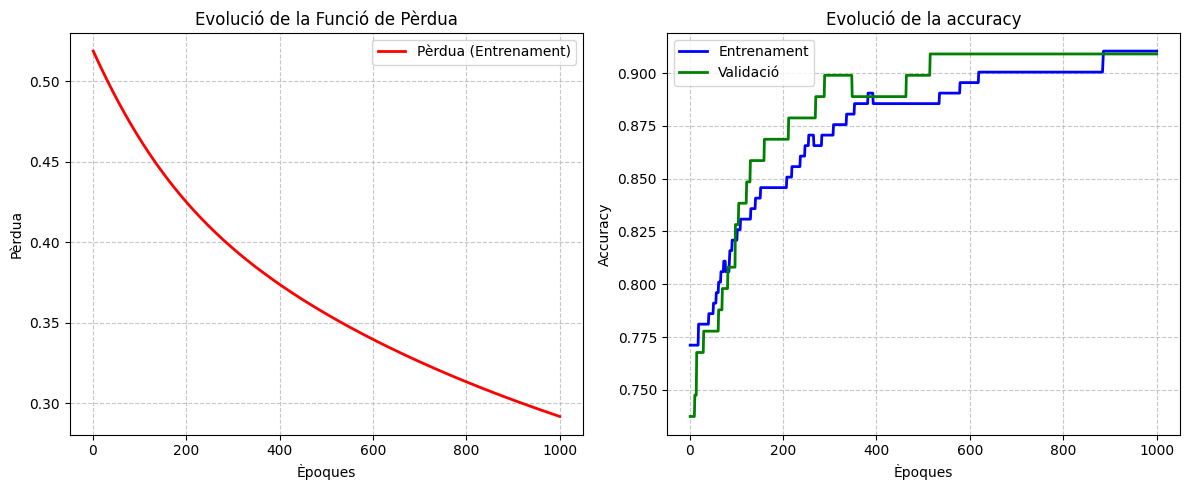

In [7]:
### CODI FET PER GEMINI

# Creem l'eix X corresponent al nombre d'èpoques
epoques = range(1, EPOCHS + 1)

# Configurem la mida general de la figura
plt.figure(figsize=(12, 5))

# --- Gràfic 1: Funció de pèrdua (Loss) ---
plt.subplot(1, 2, 1) # 1 fila, 2 columnes, posició 1
plt.plot(epoques, losses, 'r-', label='Pèrdua (Entrenament)', linewidth=2)
plt.title('Evolució de la Funció de Pèrdua')
plt.xlabel('Èpoques')
plt.ylabel('Pèrdua')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- Gràfic 2: Precisió (Accuracy) ---
plt.subplot(1, 2, 2) # 1 fila, 2 columnes, posició 2
plt.plot(epoques, accuracies, 'b-', label='Entrenament', linewidth=2)
plt.plot(epoques, accuracies_val, 'g-', label='Validació', linewidth=2)
plt.title('Evolució de la accuracy')
plt.xlabel('Èpoques')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustem l'espaiat per evitar que els textos se superposin
plt.tight_layout()

# Mostrem el gràfic
plt.show()

---
# Tasques

**Pistes.**
- Fixau llavors aleatòries per garantir la reproductibilitat.
- Les decisions (arquitectura, hiperparàmetres, tria de model) es prenen amb el conjunt de **validació**. El **test** només s'usa per als resultats finals.

### Tasca 1

Implementar i entrenar una xarxa amb **tres capes lineals** seguides (2 → 8 → 8 → 1) **sense cap funció d'activació entre elles**, entrenada sobre les dades sintètiques de l'exemple. **Comparau** si obtindrà millors resultats que el perceptró d'una sola capa.

### Tasca 2

Repetiu l'experiment anterior afegint una **ReLU** després de cada capa oculta (`nn.ReLU()` o `torch.relu`). Comparau els resultats obtinguts amb els anterior i amb el perceptró sobre el **mateix** conjunt de dades.

### Tasca 3

Entrenar un model de `PyTorch` amb el conjunt de dades del Titanic que vàrem treballar a la sessió anterior.

**Dades.** Podeu usar el fitxer de la sessió anterior o carregar-lo amb `seaborn`:

```python
import seaborn as sns
titanic = sns.load_dataset("titanic")
```
